# Data loading

This notebook loads the Letterboxd ratings (partial) dataset and inspects its structure. 
Initial steps include loading the dataset, inspecting its structure, and computing basic statistics. 

## Dataset overview

In [2]:
import pandas as pd

In [3]:
ratings = pd.read_parquet("../data/raw/ratings.parquet")

In [4]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 10462257 entries, 0 to 10462256
Data columns (total 4 columns):
 #   Column    Dtype  
---  ------    -----  
 0   user      uint16 
 1   movie_id  uint32 
 2   title     str    
 3   rating    float32
dtypes: float32(1), str(1), uint16(1), uint32(1)
memory usage: 345.5 MB


In [5]:
ratings.head(5)

,user,movie_id,title,rating
0,0,1045381,scream-7,0.5
1,0,1090728,ella-mccay,4.0
2,0,977342,zootopia-2,3.5
3,0,871148,wicked-for-good,4.0
4,0,358757,now-you-see-me-now-you-dont-2025,4.0


In [6]:
ratings.shape

(10462257, 4)

In [7]:
ratings.columns

Index(['user', 'movie_id', 'title', 'rating'], dtype='str')

In [8]:
ratings.dtypes

user         uint16
movie_id     uint32
title           str
rating      float32
dtype: object

In [9]:
ratings["rating"].describe()

count    1.046226e+07
mean     3.283513e+00
std      1.055683e+00
min      5.000000e-01
25%      2.500000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [10]:
ratings["user"].nunique()

6519

In [11]:
ratings["movie_id"].nunique()

281045

The dataset contains ratings in the website Letterboxd of 6519 users of 281045 movies. 

There are over 10 million ratings recorded. This is a subset of the site but from the most popular users. 

For each rating we have information of the user, the name and id of the movie and a rating from 0.5 to 5.0. 

## Rating distribution

In [12]:
ratings["rating"].value_counts().sort_index()

rating
0.5     190095
1.0     361082
1.5     365872
2.0     859407
2.5     979630
3.0    1981222
3.5    1899613
4.0    2101217
4.5     875288
5.0     848831
Name: count, dtype: int64

In [13]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


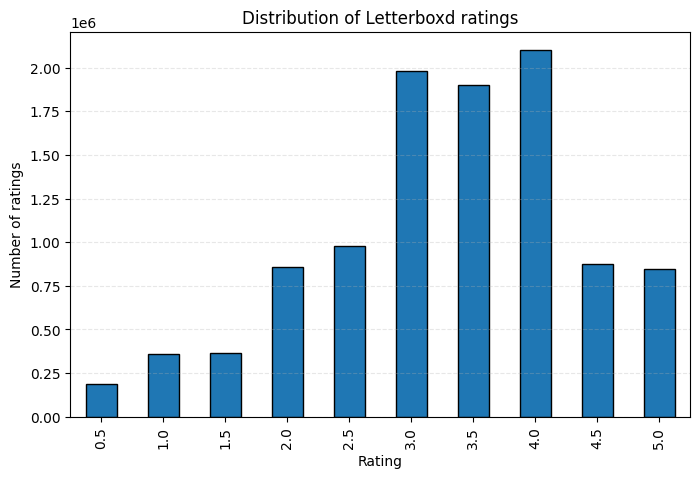

In [33]:
plt.figure(figsize=(8,5))

ratings["rating"].value_counts().sort_index().plot(kind="bar", color="tab:blue", edgecolor="black")

plt.xlabel("Rating")
plt.ylabel("Number of ratings")
plt.title("Distribution of Letterboxd ratings")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

The distribution of the ratings shows a strong concentration in the region *3.0-4.0*. The mean is *3.28*. Very low ratings (under 2.0) are rare. 

There is a *positive rating bias*. Users are more likely to rate movies they enjoy or they expect to enjoy. 

The rating range is from *0.5 to 5.0 with increments of 0.5 points*. This gives us 10 possible values. For future modeling we will treat this metric as continuous for ease of use. 

In [45]:
ratings.groupby(["movie_id","title"]).size().sort_values(ascending=False).head(10)

movie_id  title                            
277064    barbie                               5541
426406    parasite-2019                        5218
353117    get-out-2017                         5110
475370    knives-out-2019                      5110
838140    the-substance                        5070
1116600   sinners-2025                         5031
474474    everything-everywhere-all-at-once    5007
371378    dune-2021                            4943
240344    la-la-land                           4927
348914    the-batman                           4891
dtype: int64

In [46]:
ratings["user"].value_counts().head(10)

user
1917    9990
509     9952
4360    9896
1031    9793
2622    9642
595     9638
5829    9495
5694    9409
174     9376
2414    9355
Name: count, dtype: int64

In [42]:
ratings.sort_values("rating", ascending=False)["title"].head(10)

1220269     spider-man-into-the-spider-verse
5735619                                ariel
9923929                              83-2021
9107931                           drive-2011
10128507                     mickeys-trailer
6256155                from-here-to-eternity
6256157                            stalag-17
5212353                     django-unchained
5212360      the-perks-of-being-a-wallflower
6955726                  the-spectacular-now
Name: title, dtype: str